In [44]:
import xarray as xr
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

In [55]:
outroot = '/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessed_data/vertical_profiles'
member = '001'
freq_input = 'monthly'
stat = 'mean'
model = 'CESM2'
varia = 'dissic'#'dissic'#'dissic'#'thetao'##'o2'

if varia == 'thetao':
    unit = "°C"
    vmin = -4
    vmax = 4
    cmap = 'cmo.balance'
elif varia == 'dissic':
    unit = r'mmol m$^{-3}$'
    vmin = -160
    vmax = 160
    cmap = 'cmo.balance_r'
elif varia == 'o2':
    unit = r'mmol m$^{-3}$'
    vmin = -40
    vmax = 40
    cmap = 'BrBG'

runs = ['esm-piControl','esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0']

dd = dict()
for rdx,run in enumerate(runs):
    save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
    save_string = f'{varia}_{model}_{run}_{member}_global_{stat}.nc'
    dd[run] = xr.open_dataset(f'{save_dir}/{save_string}')#.groupby('time.year').mean('time')


troot = '/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_series'
taria = 'tas'
dt = dict()
for rdx,run in enumerate(runs):
    tave_dir = f'{troot}/{taria}/{model}/{run}/{member}/{freq_input}/global_{stat}'
    tave_string = f'{taria}_{model}_{run}_{member}_global_{stat}.nc'
    dt[run] = xr.open_dataset(f'{tave_dir}/{tave_string}')#.groupby('time.year').mean('time')


/tmp/ipykernel_262517/3086119779.py:30: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  dd[run] = xr.open_dataset(f'{save_dir}/{save_string}')#.groupby('time.year').mean('time')
/tmp/ipykernel_262517/3086119779.py:30: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  dd[run] = xr.open_dataset(f'{save_dir}/{save_string}')#.groupby('time.year').mean('time')
/tmp/ipykernel_262517/3086119779.py:30: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.


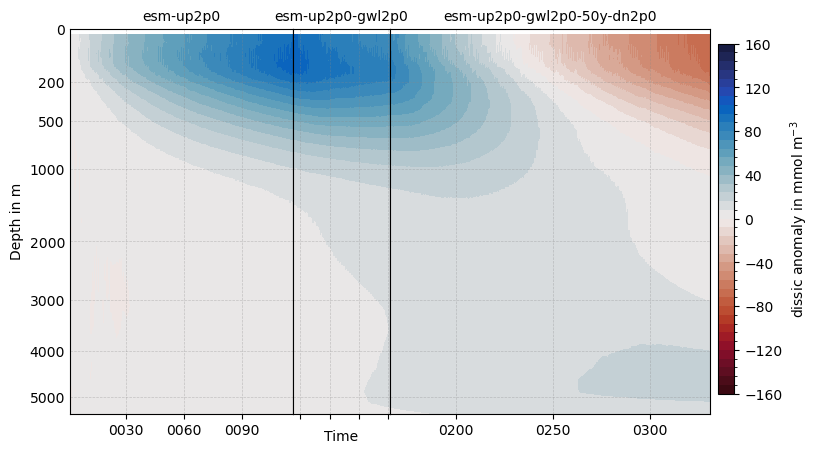

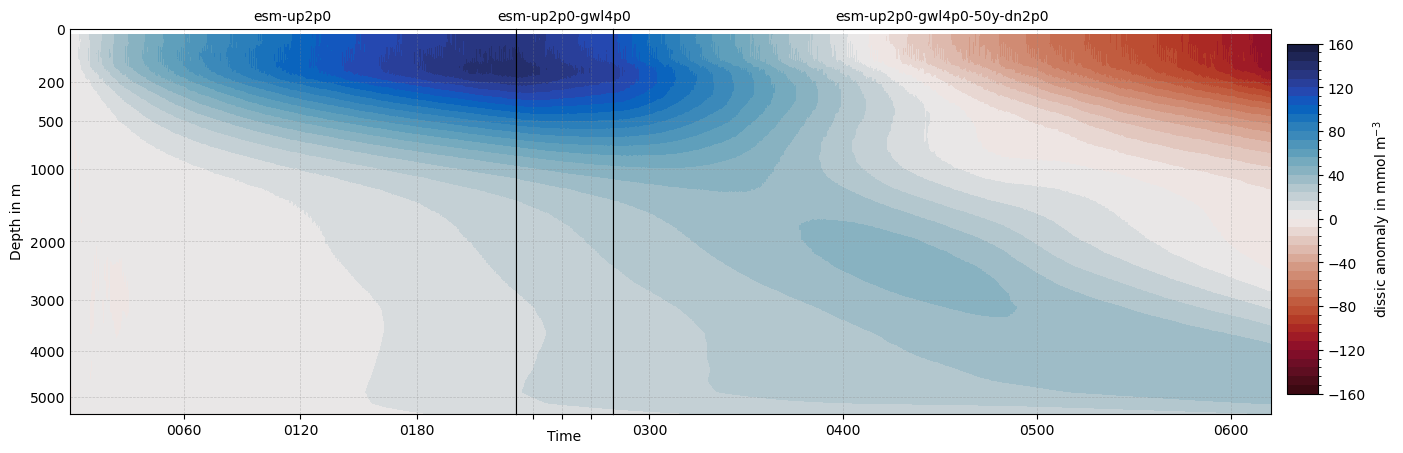

In [56]:
# ----------------------------------------------------------
# branches
# ----------------------------------------------------------

cycles = {
    "2K": "esm-up2p0-gwl2p0",
    "4K": "esm-up2p0-gwl4p0",
}

#vmin, vmax = -4,4 #-160, 160 , #-40, 40

# ----------------------------------------------------------
# reference
# ----------------------------------------------------------

ref_profile = (
    dd["esm-up2p0"][f"{varia}_global_{stat}"]
    .isel(time=slice(0, 12))
    .mean("time")
)

# ----------------------------------------------------------
# helpers
# ----------------------------------------------------------

def cut_50y(da, run):
    if "50y-dn2p0" in run:
        return da.isel(time=slice(0, 50 * 12))
    return da

def nyears(da):
    return da.sizes["time"] / 12

def t0(da):
    return da.time.values[0]

# ----------------------------------------------------------
# plot
# ----------------------------------------------------------

def plot(ax, da, cmap):

    da = (da - ref_profile).transpose("z_t", "time")

    z = da["z_t"].values

    # ------------------------------------------------------
    # NONLINEAR DEPTH TRANSFORM
    # ------------------------------------------------------

    zmax = np.nanmax(z)
    alpha = 0.6

    z_trans = (z / zmax) ** alpha
    da = da.assign_coords(z_t=z_trans)

    im = da.plot.contourf(
        ax=ax,
        x="time",
        y="z_t",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=41,
        add_colorbar=False,
    )

    # ------------------------------------------------------
    # ROUND PHYSICAL DEPTH TICKS (IMPORTANT PART)
    # ------------------------------------------------------

    tick_phys = np.array([
        0, 200, 500, 1000,
        2000, 3000, 4000, 5000
    ])*100.

    # keep only valid ones
    tick_phys = tick_phys[tick_phys <= zmax]

    # transform them using SAME mapping
    tick_trans = (tick_phys / zmax) ** alpha

    ax.set_yticks(tick_trans)
    ax.set_yticklabels([str(int(t/100.)) for t in tick_phys])

    ax.invert_yaxis()

    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis="y", length=0)
    ax.margins(x=0)

    return im

# ----------------------------------------------------------
# LOOP OVER CASES
# ----------------------------------------------------------

for cycle, gwl_run in cycles.items():

    # ------------------------------------------------------
    # datasets
    # ------------------------------------------------------

    esm = dd["esm-up2p0"][f"{varia}_global_{stat}"]
    gwl = dd[gwl_run][f"{varia}_global_{stat}"]
    rec = dd[f"{gwl_run}-50y-dn2p0"][f"{varia}_global_{stat}"]

    rec = cut_50y(rec, "x")

    # ------------------------------------------------------
    # causal truncation
    # ------------------------------------------------------

    t_mid = t0(gwl)
    t_right = t0(rec)

    esm_cut = esm.sel(time=slice(None, t_mid))
    gwl_cut = gwl.sel(time=slice(None, t_right))
    rec_cut = rec

    datasets = [esm_cut, gwl_cut, rec_cut]

    # ------------------------------------------------------
    # widths (years per panel)
    # ------------------------------------------------------

    widths = [nyears(d) for d in datasets]
    total_years = sum(widths)

    # ------------------------------------------------------
    # FIGURE SIZE SCALES WITH TOTAL YEARS
    # ------------------------------------------------------

    fig_width = max(1, total_years/40)
    fig_height = 5

    fig = plt.figure(figsize=(fig_width, fig_height))

    gs = fig.add_gridspec(
        1, 3,
        width_ratios=widths,
        wspace=0.0,   # no gaps
        right=0.9
    )

    axes = []
    ims = []

    labels = [
        "esm-up2p0",
        gwl_run,
        f"{gwl_run}-50y-dn2p0",
    ]

    # ------------------------------------------------------
    # plotting
    # ------------------------------------------------------

    for i, da in enumerate(datasets):
        ax = fig.add_subplot(gs[0, i])

        ims.append(plot(ax, da, cmap))

        ax.set_title(labels[i],fontsize=10)

        ax.set_xlim(da.time.values[0], da.time.values[-1])

        axes.append(ax)

    axes[0].set_ylabel("Depth in m")

    for adx,axi in enumerate(axes):
        if adx != 0:
            axi.set_yticklabels([])
        axi.grid(alpha=0.4,linewidth=0.5,linestyle='--',color='#888888')
        
    for adx,axi in enumerate(axes):
        if adx == 1:
            axi.set_xticklabels([])
            axi.set_xlabel("Time")


    # ------------------------------------------------------
    # colorbar
    # ------------------------------------------------------

    cax = fig.add_axes([0.91,0.15,0.02,0.7])
    fig.colorbar(
        ims[0],
        cax=cax,
        fraction=0.03,
        pad=0.02,
        label=f"{varia} anomaly in {unit}"
    )

    plot_dir = f'./../03_plots/vertical_profile_global_statistic/{varia}/{model}/global_{stat}/ref_first_year_of_rampup'
    os.makedirs(plot_dir,exist_ok = True)
    plot_filename = f'vertical_profile_{varia}_{model}_global_{stat}_ref_first_year_of_rampup_{cycle}cycle.png'
    fig.savefig(f'{plot_dir}/{plot_filename}',dpi=150,transparent=True)
    plt.show()

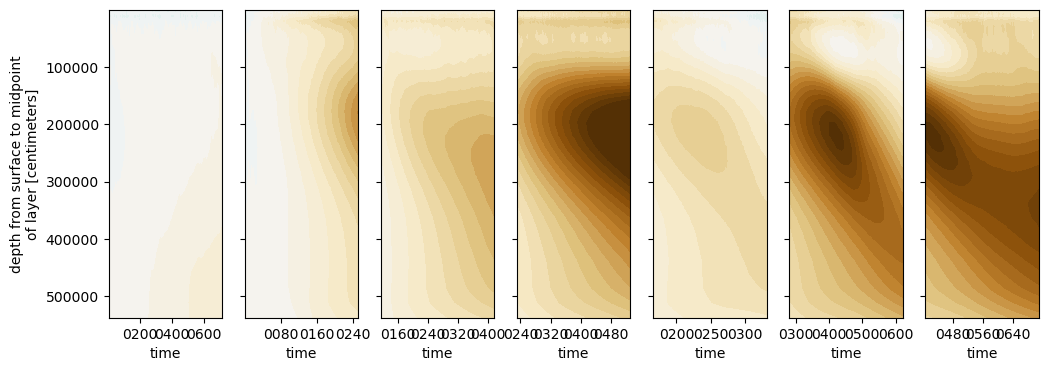

In [28]:
ref_profile = dd['esm-up2p0'][f'{varia}_global_{stat}'].isel(time=slice(0,12)).mean("time")

fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(dd.keys()):
    da = (dd[key][f'{varia}_global_{stat}'] - ref_profile).T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="z_t",
        cmap="BrBG",#"cmo.balance",
        vmin=-40,
        vmax=40,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

/tmp/ipykernel_262517/2818803836.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


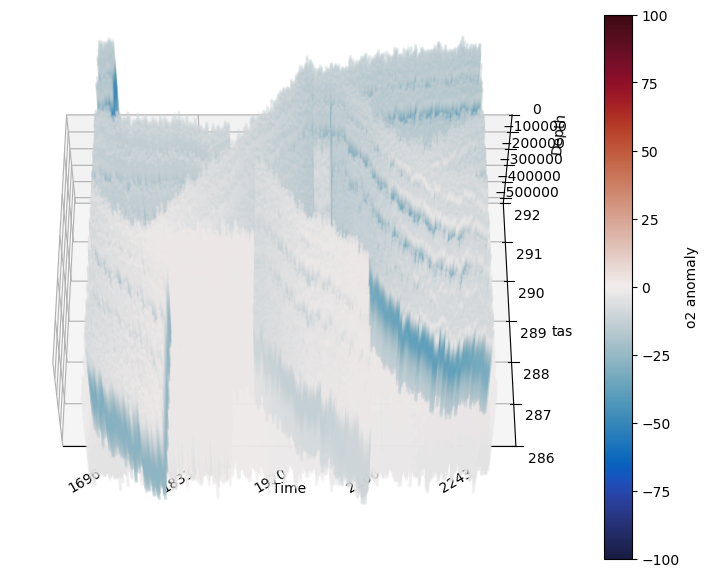

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.colors import Normalize
import cmocean as cmo

# ----------------------------------------------------------
# reference
# ----------------------------------------------------------

ref_profile = (
    dd["esm-up2p0"][f"{varia}_global_{stat}"]
    .isel(time=0)
)

#z_new = np.arange(
#    0,
#    dd["esm-up2p0"].z_t.max().values,
#    10
#)

# ----------------------------------------------------------
# figure
# ----------------------------------------------------------

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

norm = Normalize(vmin=-100, vmax=100)
cmap = 'cmo.balance'

# convert time → matplotlib numeric dates
# (works for datetime64 and cftime converted via pandas)
def to_mpl_time(t):
    return mdates.date2num(np.array(t, dtype="datetime64[ns]"))

# ----------------------------------------------------------
# loop
# ----------------------------------------------------------

for kdx,key in enumerate(dd.keys()):

    da = (
        dd[key][f"{varia}_global_{stat}"]
        - ref_profile
    ).transpose("z_t", "time")

    # --------------------------------------------------
    # interpolate to 10 m grid
    # --------------------------------------------------
    da = da.interp(z_t=np.arange(0, da.z_t.max(), 5000))

    # Only keep first 50 times (600 monthly values)
    #if key in ["esm-up2p0-gwl2p0","esm-up2p0-gwl4p0"]:
    #    da = da.isel(time=slice(0, 50))
    #    dt[key] = dt[key].isel(time=slice(0, 50))
    
    
    time = to_mpl_time(da.time.values)
    depth = da.z_t.values.astype(float)

    ts = dt[key][f"{taria}_global_{stat}"].sel(time=da.time)

    # same real time axis
    temp = ts.values.astype(float)

    # expand grid
    T, Z = np.meshgrid(time, depth)
    Y = np.tile(temp, (len(depth), 1))

    # scatter representation of curtain
    ax.scatter(
        T.ravel(),
        Y.ravel(),
        -Z.ravel(),
        c=da.values.ravel(),
        cmap=cmap,
        norm=norm,
        s=5,
        alpha=0.2,
        linewidths=0,
        zorder=kdx,
    )

# ----------------------------------------------------------
# formatting
# ----------------------------------------------------------

ax.set_xlabel("Time")
ax.set_ylabel(f"{taria}")
ax.set_ylim([286,292])
ax.set_zlabel("Depth")
ax.set_zlim([-500000,0])


ax.set_zlim(-depth.max(), 0)

# format time axis properly
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label=f"{varia} anomaly")


ax.set_box_aspect((3, 2, 1))
ax.view_init(elev=55, azim=270)

plt.tight_layout()
plt.show()